In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np

In [6]:
data = pd.read_csv('/content/Global_Cybersecurity_Threats_2015-2024.csv')

data

,Country,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours)
0,China,2019,Phishing,Education,80.53,773169,Hacker Group,Unpatched Software,VPN,63
1,China,2019,Ransomware,Retail,62.19,295961,Hacker Group,Unpatched Software,Firewall,71
2,India,2017,Man-in-the-Middle,IT,38.65,605895,Hacker Group,Weak Passwords,VPN,20
3,UK,2024,Ransomware,Telecommunications,41.44,659320,Nation-state,Social Engineering,AI-based Detection,7
4,Germany,2018,Man-in-the-Middle,IT,74.41,810682,Insider,Social Engineering,VPN,68
...,...,...,...,...,...,...,...,...,...,...
2995,UK,2021,Ransomware,Government,51.42,190694,Unknown,Social Engineering,Firewall,52
2996,Brazil,2023,SQL Injection,Telecommunications,30.28,892843,Hacker Group,Zero-day,VPN,26
2997,Brazil,2017,SQL Injection,IT,32.97,734737,Nation-state,Weak Passwords,AI-based Detection,30
2998,UK,2022,SQL Injection,IT,32.17,379954,Insider,Unpatched Software,Firewall,9


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Country                              3000 non-null   object 
 1   Year                                 3000 non-null   int64  
 2   Attack Type                          3000 non-null   object 
 3   Target Industry                      3000 non-null   object 
 4   Financial Loss (in Million $)        3000 non-null   float64
 5   Number of Affected Users             3000 non-null   int64  
 6   Attack Source                        3000 non-null   object 
 7   Security Vulnerability Type          3000 non-null   object 
 8   Defense Mechanism Used               3000 non-null   object 
 9   Incident Resolution Time (in Hours)  3000 non-null   int64  
dtypes: float64(1), int64(3), object(6)
memory usage: 234.5+ KB


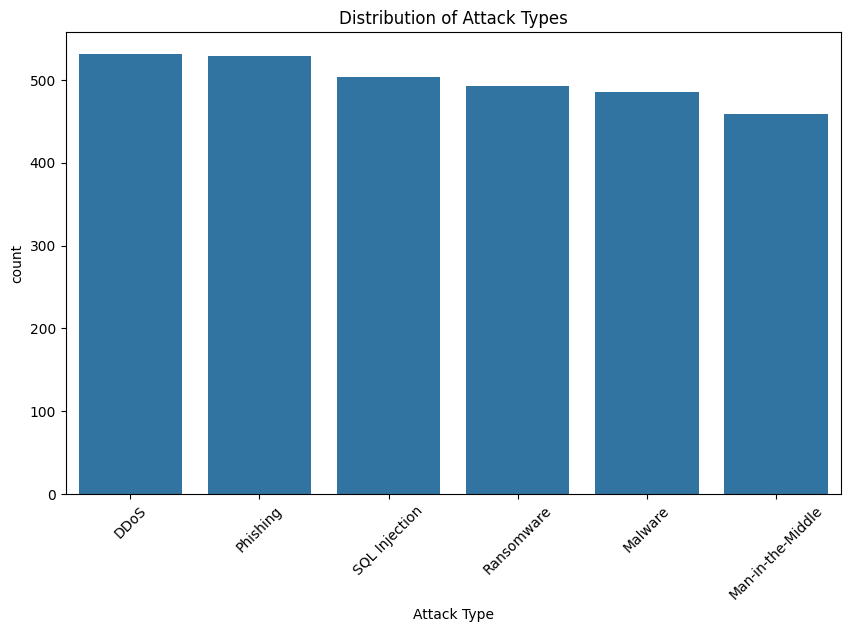

In [9]:
plt.figure(figsize=(10, 6))
sns.countplot(data=data, x='Attack Type', order=data['Attack Type'].value_counts().index)
plt.title('Distribution of Attack Types')
plt.xticks(rotation=45)
plt.savefig('attack_types_distribution.png')
plt.show()

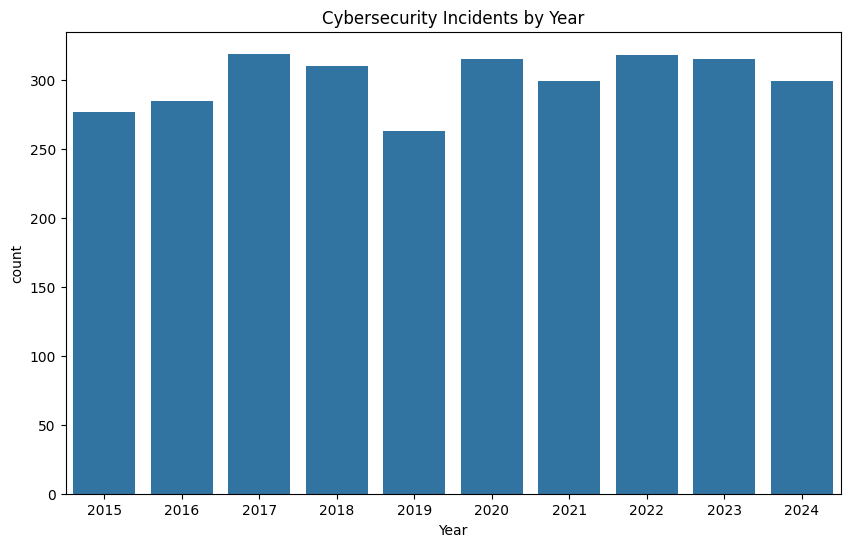

In [10]:
plt.figure(figsize=(10, 6))
sns.countplot(data=data, x='Year')
plt.title('Cybersecurity Incidents by Year')
plt.savefig('incidents_by_year.png')
plt.show()

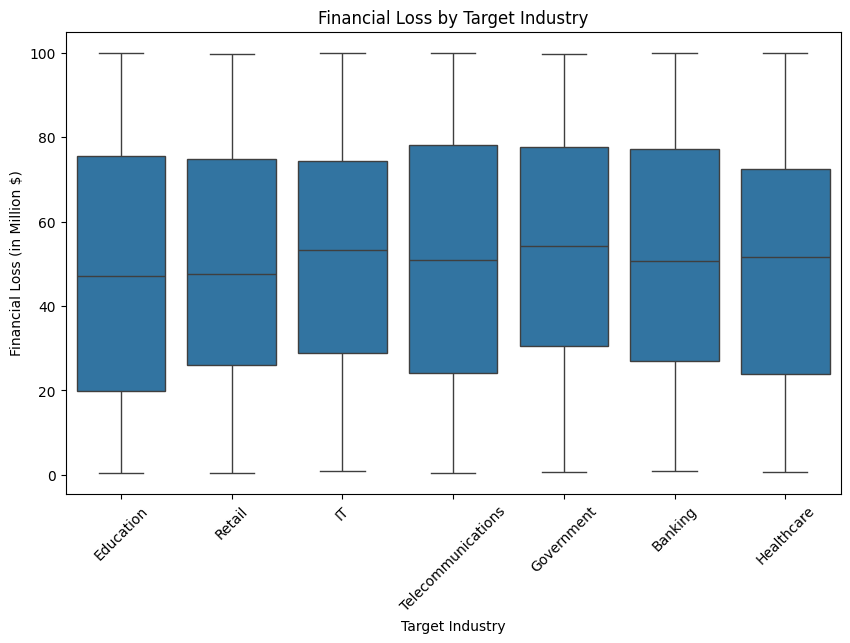

In [11]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=data, x='Target Industry', y='Financial Loss (in Million $)')
plt.title('Financial Loss by Target Industry')
plt.xticks(rotation=45)
plt.savefig('financial_loss_by_industry.png')
plt.show()

In [12]:
features = ['Country', 'Year', 'Target Industry', 'Financial Loss (in Million $)',
            'Number of Affected Users', 'Attack Source', 'Security Vulnerability Type',
            'Defense Mechanism Used', 'Incident Resolution Time (in Hours)']
target = 'Attack Type'

In [13]:
le_dict = {}
for col in ['Country', 'Target Industry', 'Attack Source', 'Security Vulnerability Type',
            'Defense Mechanism Used', 'Attack Type']:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    le_dict[col] = le

In [14]:
X = data[features]
y = data[target]

In [15]:
X

,Country,Year,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours)
0,2,2019,1,80.53,773169,0,1,4,63
1,2,2019,5,62.19,295961,0,1,3,71
2,5,2017,4,38.65,605895,0,2,4,20
3,8,2024,6,41.44,659320,2,0,0,7
4,4,2018,4,74.41,810682,1,0,4,68
...,...,...,...,...,...,...,...,...,...
2995,8,2021,2,51.42,190694,3,0,3,52
2996,1,2023,6,30.28,892843,0,3,4,26
2997,1,2017,4,32.97,734737,2,2,0,30
2998,8,2022,4,32.17,379954,1,1,3,9


In [16]:
y

,Attack Type
0,3
1,4
2,2
3,4
4,2
...,...
2995,4
2996,5
2997,5
2998,5


In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [19]:
y_pred = model.predict(X_test)

In [20]:
y_test_decoded = le_dict['Attack Type'].inverse_transform(y_test)
y_pred_decoded = le_dict['Attack Type'].inverse_transform(y_pred)

In [21]:
print("\nClassification Report:")
print(classification_report(y_test_decoded, y_pred_decoded))
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")


Classification Report:
                   precision    recall  f1-score   support

             DDoS       0.14      0.15      0.15       111
          Malware       0.21      0.22      0.21        97
Man-in-the-Middle       0.16      0.11      0.13        99
         Phishing       0.14      0.15      0.14       103
       Ransomware       0.14      0.18      0.15        79
    SQL Injection       0.18      0.16      0.17       111

         accuracy                           0.16       600
        macro avg       0.16      0.16      0.16       600
     weighted avg       0.16      0.16      0.16       600

Accuracy: 0.16


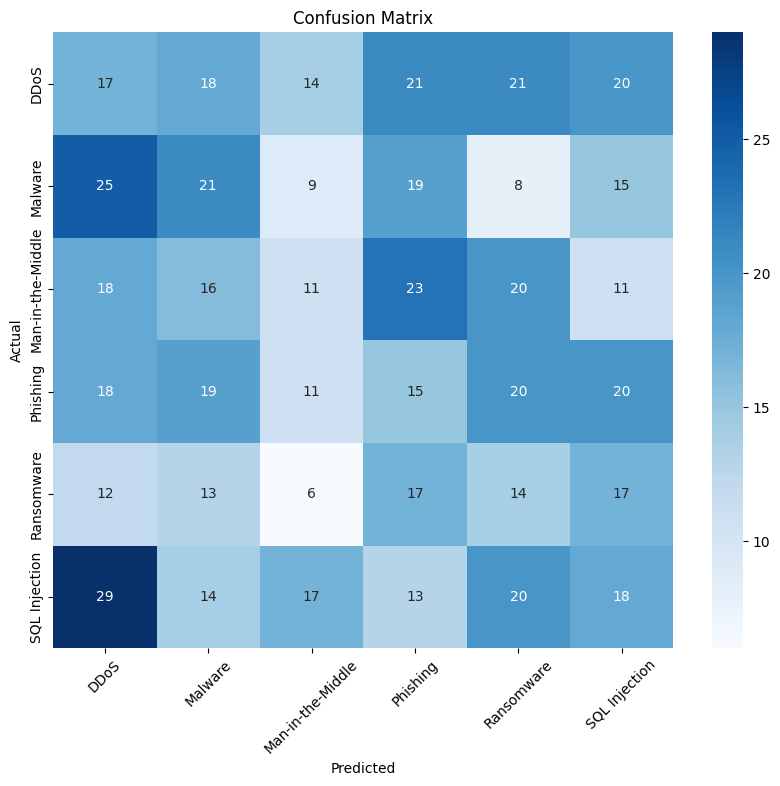

In [22]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_dict['Attack Type'].classes_,
            yticklabels=le_dict['Attack Type'].classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.xticks(rotation=45)
plt.savefig('confusion_matrix.png')
plt.show()

In [23]:
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importance:")
print(feature_importance)


Feature Importance:
                               Feature  Importance
3        Financial Loss (in Million $)    0.177794
4             Number of Affected Users    0.174537
8  Incident Resolution Time (in Hours)    0.154882
1                                 Year    0.104331
0                              Country    0.097105
2                      Target Industry    0.087238
7               Defense Mechanism Used    0.075688
5                        Attack Source    0.066456
6          Security Vulnerability Type    0.061969


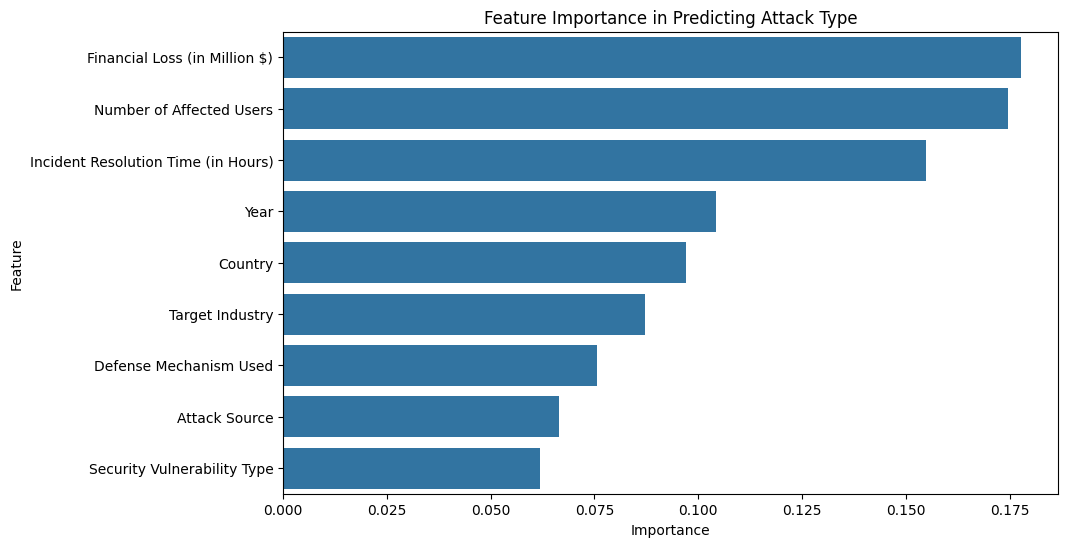

In [24]:
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='Importance', y='Feature')
plt.title('Feature Importance in Predicting Attack Type')
plt.savefig('feature_importance.png')
plt.show()

In [25]:
print("\nThreat Intelligence Insights:")
print(f"Most common attack type: {data['Attack Type'].mode()[0]} (encoded)")
print(f"Industry with highest average financial loss: {data.groupby('Target Industry')['Financial Loss (in Million $)'].mean().idxmax()} (encoded)")
print(f"Average incident resolution time: {data['Incident Resolution Time (in Hours)'].mean():.2f} hours")


Threat Intelligence Insights:
Most common attack type: 0 (encoded)
Industry with highest average financial loss: 2 (encoded)
Average incident resolution time: 36.48 hours
